c:\Users\22252705\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\nolds\measures.py:31: RuntimeWarning: fitting mode 'RANSAC' requires the package sklearn, using 'poly' instead
  warnings.warn(



Final results
System              LLE bits/ms
-----------------------------------
Chua               1.7648296155
Jerk               0.2444181531


c:\Users\22252705\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\nolds\measures.py:31: RuntimeWarning: fitting mode 'RANSAC' requires the package sklearn, using 'poly' instead
  warnings.warn(


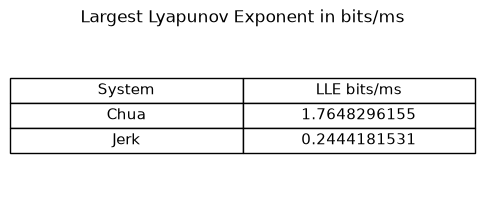

In [21]:
# Import libraries
import numpy as np
import nolds
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. Load data function
# ============================================================

def load_data(file_path):
    """
    Tries to load a numeric file using common formats.
    """
    load_options = [
        {},
        {"skiprows": 1},
        {"delimiter": ","},
        {"delimiter": ";"},
        {"delimiter": ",", "skiprows": 1},
        {"delimiter": ";", "skiprows": 1},
    ]

    for options in load_options:
        try:
            return np.loadtxt(file_path, **options)
        except Exception:
            pass

    raise ValueError(f"Could not load the file: {file_path}")


# ============================================================
# 2. Largest Lyapunov exponent calculation function
# ============================================================

def calculate_lyapunov_bits_ms(
    filename,
    emb_dim,
    lag,
    min_tsep,
    trajectory_len,
    signal_column=1,
    fs=10000
):
    """
    Loads a time series file, normalizes the signal,
    calculates the largest Lyapunov exponent using Rosenstein's method,
    and returns only the result in bits/ms.
    """

    file_path = Path(filename)

    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    data = load_data(file_path)

    if data.ndim == 1:
        x = data
    else:
        x = data[:, signal_column]

    x = np.asarray(x, dtype=float)

    # Remove NaN and infinite values
    x = x[np.isfinite(x)]

    # Normalize signal
    x = x - np.mean(x)
    x = x / np.std(x)

    # LLE in nats/sample
    lle_nats_per_sample = nolds.lyap_r(
        x,
        emb_dim=emb_dim,
        lag=lag,
        min_tsep=min_tsep,
        trajectory_len=trajectory_len,
        fit="RANSAC"
    )

    # Convert nats/sample to bits/sample
    lle_bits_per_sample = lle_nats_per_sample / np.log(2)

    # Convert bits/sample to bits/ms
    lle_bits_per_ms = lle_bits_per_sample * fs / 1000

    return {
        "System": filename.replace("_ai0.dat", ""),
        "LLE bits/ms": lle_bits_per_ms
    }


# ============================================================
# 3. Run analysis for both files
# ============================================================

results = []

results.append(
    calculate_lyapunov_bits_ms(
        filename="Chua_ai0.dat",
        emb_dim=7,
        lag=3,
        min_tsep=6,
        trajectory_len=22,
        signal_column=1,
        fs=10000
    )
)

results.append(
    calculate_lyapunov_bits_ms(
        filename="Jerk_ai0.dat",
        emb_dim=9,
        lag=10,
        min_tsep=5,
        trajectory_len=15,
        signal_column=1,
        fs=10000
    )
)


# ============================================================
# 4. Print final table
# ============================================================

print("\nFinal results")
print("=" * 35)
print(f"{'System':<10} {'LLE bits/ms':>20}")
print("-" * 35)

for result in results:
    print(
        f"{result['System']:<10} "
        f"{result['LLE bits/ms']:>20.10f}"
    )


# ============================================================
# 5. Plot final table only
# ============================================================

table_data = [
    [
        result["System"],
        f"{result['LLE bits/ms']:.10f}"
    ]
    for result in results
]

column_labels = [
    "System",
    "LLE bits/ms"
]

fig, ax = plt.subplots(figsize=(6, 2.2))
ax.axis("off")

table = ax.table(
    cellText=table_data,
    colLabels=column_labels,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)

plt.title("Largest Lyapunov Exponent in bits/ms")
plt.show()